<a href="https://colab.research.google.com/github/bcramp/ML/blob/main/HW2/data_prep_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---

HW 2

Title: Data Prep Analysis of the Cybersecurity Intrusion Detection Dataset

Name: Brennen Cramp

Date: 9/10/2026

---

# Step 1: Load the dataset into a Pandas DataFrame

In [63]:
# Import Pandas for handling tabular data
# Import NumPy for handling scientific computing and math operations
import pandas as pd
import numpy as np

# Step 1: Since the downloaded CSV was uploaded directly to the Colab session files,
# load the file into a Pandas DataFrame
df = pd.read_csv('cybersecurity_intrusion_data.csv')

# Step 2: Inspect and analyze features

In [64]:
# Step 2: Use structural inspection methods (head(), info(), describe()) to analyze features such as network_packet_size, session_duration, login_attempts, protocol_type, and browser_type.
print("--- Step 2: Inspection ---")
print("\nFirst 5 rows of the dataset:")
df.head()

--- Step 2: Inspection ---

First 5 rows of the dataset:


,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


In [65]:
print("General information about the cybersecurity intrusion dataset:\n")
df.info()

print("\nSummary statistics of numerical columns:\n")
df.describe()

General information about the cybersecurity intrusion dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   session_id           9537 non-null   object 
 1   network_packet_size  9537 non-null   int64  
 2   protocol_type        9537 non-null   object 
 3   login_attempts       9537 non-null   int64  
 4   session_duration     9537 non-null   float64
 5   encryption_used      7571 non-null   object 
 6   ip_reputation_score  9537 non-null   float64
 7   failed_logins        9537 non-null   int64  
 8   browser_type         9537 non-null   object 
 9   unusual_time_access  9537 non-null   int64  
 10  attack_detected      9537 non-null   int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 819.7+ KB

Summary statistics of numerical columns:



,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access,attack_detected
count,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000
mean,500.430639,4.032086,792.745312,0.331338,1.517773,0.149942,0.447101
std,198.379364,1.963012,786.560144,0.177175,1.033988,0.357034,0.497220
min,64.000000,1.000000,0.500000,0.002497,0.000000,0.000000,0.000000
25%,365.000000,3.000000,231.953006,0.191946,1.000000,0.000000,0.000000
50%,499.000000,4.000000,556.277457,0.314778,1.000000,0.000000,0.000000
75%,635.000000,5.000000,1105.380602,0.453388,2.000000,0.000000,1.000000
max,1285.000000,13.000000,7190.392213,0.924299,5.000000,1.000000,1.000000


In [66]:
# Get summary statistics for specific columns (network_packet_size, session_duration, login_attempts, protocol_type, and browser_type)
df[['network_packet_size', 'session_duration', 'login_attempts', 'protocol_type', 'browser_type']].describe()

# IMPORTANT NOTE: protocol_type and browser_type will not appear here since they contain categorical/object types and not numerical

,network_packet_size,session_duration,login_attempts
count,9537.000000,9537.000000,9537.000000
mean,500.430639,792.745312,4.032086
std,198.379364,786.560144,1.963012
min,64.000000,0.500000,1.000000
25%,365.000000,231.953006,3.000000
50%,499.000000,556.277457,4.000000
75%,635.000000,1105.380602,5.000000
max,1285.000000,7190.392213,13.000000


In [67]:
# Get summary statistics for the protocol_type column
df['protocol_type'].describe()

,protocol_type
count,9537
unique,3
top,TCP
freq,6624


In [68]:
# Get summary statistics for the browser_type column
df['browser_type'].describe()

,browser_type
count,9537
unique,5
top,Chrome
freq,5137


# Step 3: Drop any non-informative identifiers

In [69]:
# Step 3: Drop any non-informative identifiers
print("--- Step 3: Drop Non-informative Identifiers ---")

# Print the number of unique values in each column
print("\nNumber of unique values in each column:")
print(df.nunique())

# Drop non-informative identifier columns
cols_to_drop = ['session_id']
df.drop(columns=cols_to_drop, axis=1, inplace=True)

--- Step 3: Drop Non-informative Identifiers ---

Number of unique values in each column:
session_id             9537
network_packet_size     959
protocol_type             3
login_attempts           13
session_duration       9532
encryption_used           2
ip_reputation_score    9537
failed_logins             6
browser_type              5
unusual_time_access       2
attack_detected           2
dtype: int64


# Step 4: Quantify missing values and implement a structured imputation strategy

In [70]:
# Step 4.1: Quantify any missing values across the columns.
print("--- Step 4.1: Quantify any missing values across the columns ---")

# Quantify missing values per column
print("\n--- Missing Values Count ---")
print(df.isnull().sum())

# Check each of the String/Object values for N/A types which can be associated with 'null'
print("\nProtocol Types Values Count:")
print(df['protocol_type'].value_counts())

print("\nBrowser Types Values Count:")
print(df['browser_type'].value_counts())

print("\nEncryption Used Values Count:")
print(df['encryption_used'].value_counts())

--- Step 4.1: Quantify any missing values across the columns ---

--- Missing Values Count ---
network_packet_size       0
protocol_type             0
login_attempts            0
session_duration          0
encryption_used        1966
ip_reputation_score       0
failed_logins             0
browser_type              0
unusual_time_access       0
attack_detected           0
dtype: int64

Protocol Types Values Count:
protocol_type
TCP     6624
UDP     2406
ICMP     507
Name: count, dtype: int64

Browser Types Values Count:
browser_type
Chrome     5137
Firefox    1944
Edge       1469
Unknown     502
Safari      485
Name: count, dtype: int64

Encryption Used Values Count:
encryption_used
AES    4706
DES    2865
Name: count, dtype: int64


In [71]:
# Step 4.2: Implement a structured imputation strategy (using Pandas or Scikit-Learn's SimpleImputer) to handle missing entries.

# Import Scikit-Learn's SimpleImputer to handle missing entries
from sklearn.impute import SimpleImputer

print("--- Step 4.2: Implement a structured imputation strategy using Scikit-Learn's SimpleImputer ---")

# Identify numeric and categorical columns/features in the dataframe
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Next, I want to replace missing values in the numeric columns using the median (instead of mean due to extreme outliers possibly skewing the mean)
print("Replacing missing values in the numeric columns using the median values per column.")
num_imputer = SimpleImputer(strategy='median')
df[numeric_cols] = num_imputer.fit_transform(df[numeric_cols])

# Additionally, I want to replace missing values in the categorical columns using the most occurring value
print("Replacing missing values in the categorical columns using the most occurring value per column.")
cat_imputer = SimpleImputer(strategy='most_frequent')
df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

--- Step 4.2: Implement a structured imputation strategy using Scikit-Learn's SimpleImputer ---
Replacing missing values in the numeric columns using the median values per column.
Replacing missing values in the categorical columns using the most occurring value per column.


# Step 5: Isolate numerical/categorical features and apply scaling/encoding to columns

In [72]:
# Step 5: Isolate numerical and categorical features, then build a Scikit-Learn ColumnTransformer and Pipeline that applies appropriate scaling (e.g., StandardScaler)
# to numerical columns and encoding (e.g., OneHotEncoder) to categorical columns.

# Import needed functionalities from Scikit-Learn
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Create features and target (y - attack_detected)
features = df.drop(columns=['attack_detected'])
target = df['attack_detected']

# Separate numerical/categorical features from the features dataframe
num_features = features.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = features.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numerical features that will be scaled:", num_features)
print("Categorical features that will be encoded:", cat_features)

# Create individual pipelines for both feature types
num_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])
cat_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Make the pre-procesor by combining them into a single ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features)
    ]
)

# Finally, I will fit and transform the data to inspect the result
features_processed = preprocessor.fit_transform(features)

print("\nSuccessfully built preprocessor pipeline!")
print(f"Original shape: {features.shape}")
print(f"Processed matrix shape: {features_processed.shape}")

Numerical features that will be scaled: ['network_packet_size', 'login_attempts', 'session_duration', 'ip_reputation_score', 'failed_logins', 'unusual_time_access']
Categorical features that will be encoded: ['protocol_type', 'encryption_used', 'browser_type']

Successfully built preprocessor pipeline!
Original shape: (9537, 9)
Processed matrix shape: (9537, 16)


# Step 6: Compute the Pearson correlation matrix, generate Seaborn heatmap, at least two distribution plots, and one scatter plot

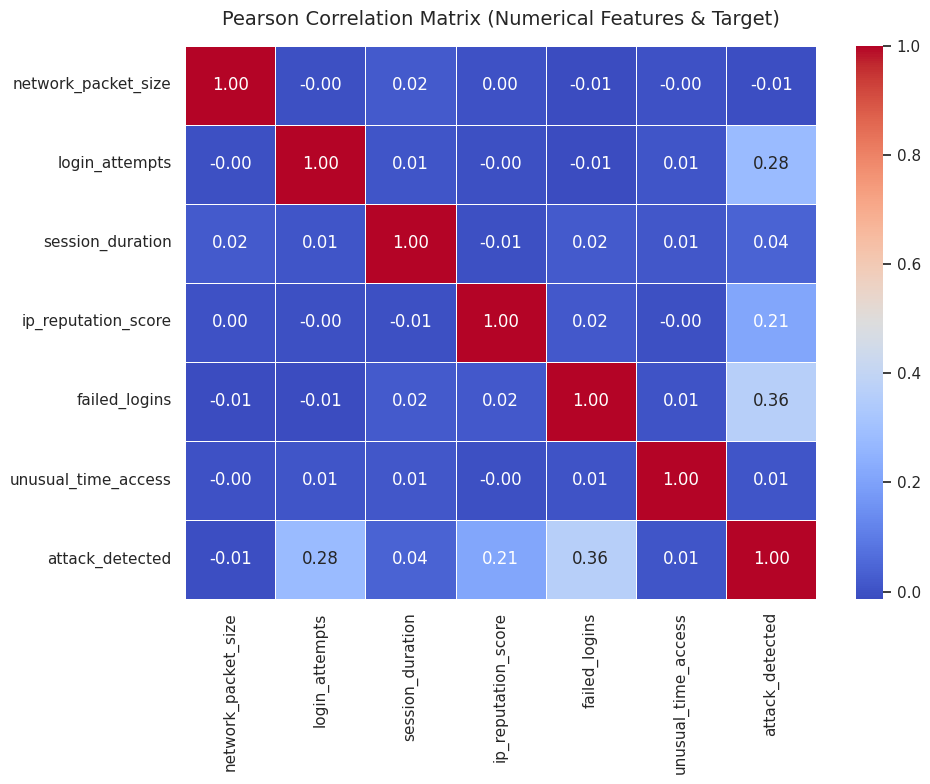

In [73]:
# Step 6: Compute the Pearson correlation matrix for the numerical features, generate a Seaborn heatmap with annotations, and create at least two
# distribution plots and one scatter plot to examine feature relationships and the target variable (attack_detected).

# Import data visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# I had issues with not being able to see the graphs so I looked up how to fix this and found this: https://seaborn.pydata.org/generated/seaborn.set_theme.html
# This sets the global aesthetic style for clean plots.
sns.set_theme(style="whitegrid")

# Keep only the numerical features plus the target variable
num_cols_with_target = num_features + ['attack_detected']
numerical_df = df[num_cols_with_target]

# Step 6.1: Pearson Correlation Matrix & Heatmap
# Set the width of the figure to 10 and height to 8
plt.figure(figsize=(10, 8))
corr_matrix = numerical_df.corr(method='pearson')

# Generate the heatmap with numeric annotations and a color map
# Set the annotation=true to tell Seaborn to write the actual numeric correlation values inside the squares
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Pearson Correlation Matrix (Numerical Features & Target)', fontsize=14, pad=15)

# Plot the graph
plt.tight_layout()
plt.show()

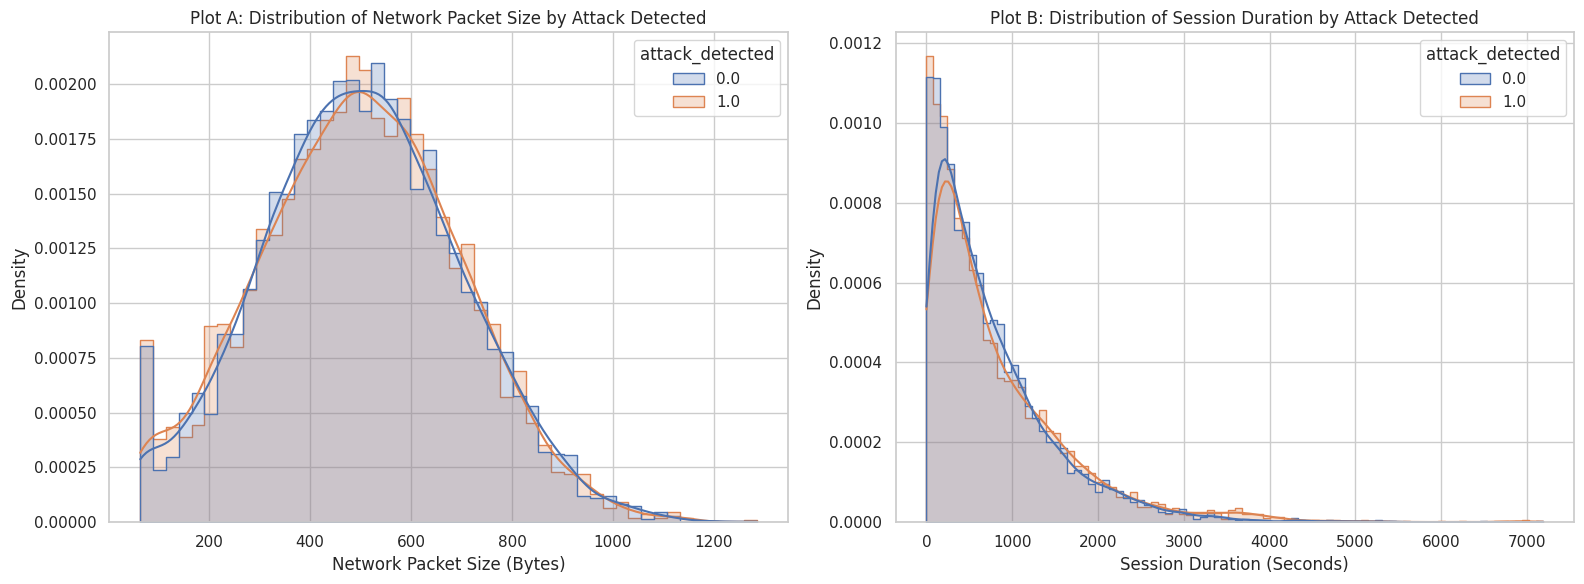

In [77]:
# Step 6.2: Create the 2 distribution plots and combine them together
# Set the width of the figure to 16 and height to 6
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Create plot A: Network Packet Size Distribution grouped by Attack Detected
# Set the Kernel Density Estimate (kde) to true for smooth curves
sns.histplot(data=df, x='network_packet_size', hue='attack_detected', kde=True, element='step', stat='density', common_norm=False, ax=axes[0])
axes[0].set_title('Plot A: Distribution of Network Packet Size by Attack Detected', fontsize=12)
axes[0].set_xlabel('Network Packet Size (Bytes)')

# Creat plot B: Session Duration Distribution grouped by Attack Detected
# Set the Kernel Density Estimate (kde) to true for smooth curves
sns.histplot(data=df, x='session_duration', hue='attack_detected', kde=True, element='step', stat='density', common_norm=False, ax=axes[1])
axes[1].set_title('Plot B: Distribution of Session Duration by Attack Detected', fontsize=12)
axes[1].set_xlabel('Session Duration (Seconds)')

# Plot the graph
plt.tight_layout()
plt.show()

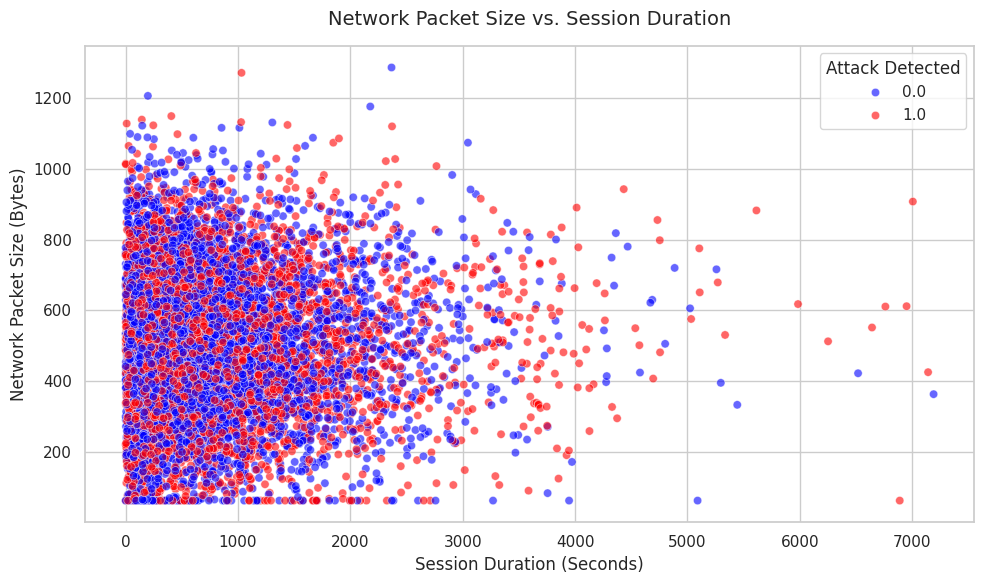

In [80]:
# Step 6.3: Create the scatter plot for the 2 selected feature relationships to the target
# Set the width of the figure to 10 and height to 6
plt.figure(figsize=(10, 6))

# Create a color map: 0 = blue, 1 = red
attack_detected_palette = {0: 'blue', 1: 'red'}

# Create plot, colored by the target, how the network packet size and session duration interact
sns.scatterplot(data=df, x='session_duration', y='network_packet_size', hue='attack_detected', alpha=0.6, palette=attack_detected_palette)
plt.title('Network Packet Size vs. Session Duration', fontsize=14, pad=15)
plt.xlabel('Session Duration (Seconds)')
plt.ylabel('Network Packet Size (Bytes)')
plt.legend(title='Attack Detected')

# Plot the graph
plt.tight_layout()
plt.show()